## Outcome Distribution — Curricular units 2nd sem (grade)

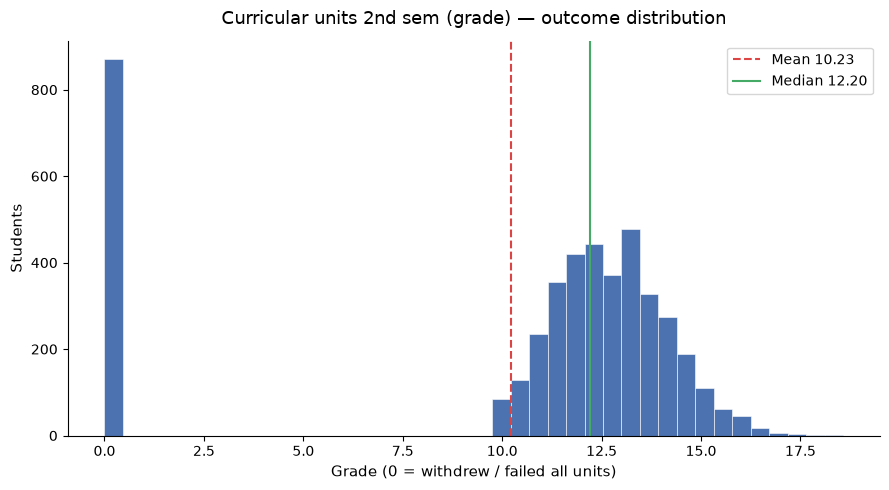

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

%matplotlib inline

RAW = Path("../data/raw/students_raw.csv")
df = pd.read_csv(RAW)
df.columns = df.columns.str.strip()
grades = df["Curricular units 2nd sem (grade)"]

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(grades, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.4)

mean, median = grades.mean(), grades.median()
ax.axvline(mean,   color="#DD4444", linewidth=1.5, linestyle="--", label=f"Mean {mean:.2f}")
ax.axvline(median, color="#44AA66", linewidth=1.5, linestyle="-",  label=f"Median {median:.2f}")

ax.set_title("Curricular units 2nd sem (grade) — outcome distribution", fontsize=13, pad=12)
ax.set_xlabel("Grade (0 = withdrew / failed all units)", fontsize=11)
ax.set_ylabel("Students", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

---

## Confounder Visualisation — `dml_ready_semantic.csv`

The sections below explore whether confounders in **X** have non-linear or heterogeneous relationships with the outcome **Y** (2nd-semester grade). This directly informs the choice of nuisance learner in DML: if non-linearities are present, flexible learners (RF, XGBoost) will outperform Lasso.

| Section | What it shows |
|---------|---------------|
| 1. LOWESS | Continuous X vs Y — shape of the relationship |
| 2. Parental education | Ordered violin plots — does the jump happen at "higher education"? |
| 3. Parental occupation | Violin plots by occupation group |
| 4. Course & application | Box plots for remaining categorical confounders |
| 5. Binary confounders | Mean grade comparison (0 vs 1) with 95% CIs |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline

SEMANTIC = Path("../data/processed/dml_ready_semantic.csv")
df = pd.read_csv(SEMANTIC)
df.columns = df.columns.str.strip()   # strip leading/trailing spaces from CSV headers

Y = "Curricular units 2nd sem (grade)"
D = "Scholarship holder"

CONTINUOUS = [
    "Previous qualification (grade)", "Admission grade",
    "Age at enrollment", "GDP", "Inflation rate", "Unemployment rate",
]
BINARY = [
    "Daytime/evening attendance", "Displaced", "Educational special needs",
    "Debtor", "Tuition fees up to date", "Gender", "International",
]

def decode_dummies(df, prefix, labels):
    """Reconstruct a Categorical series from one-hot dummy columns.

    For each row, returns the label of the dummy column that equals 1.
    prefix: column name prefix (e.g. 'Course')
    labels: ordered list of group suffixes (e.g. ['Health', 'Business_Services', ...])
    """
    cols = [f"{prefix}_{g}" for g in labels]
    raw = df[cols].idxmax(axis=1).str.replace(f"{prefix}_", "", regex=False)
    return pd.Categorical(raw, categories=labels, ordered=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
print(f"Loaded  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Y=0 rows: {(df[Y]==0).sum():,}  ({(df[Y]==0).mean()*100:.1f}%)")
print(f"D=1 rows: {(df[D]==1).sum():,}  ({(df[D]==1).mean()*100:.1f}%)")
print(f"\nContinuous X (z-scored) : {CONTINUOUS}")
print(f"Binary X (raw 0/1)      : {BINARY}")

Loaded  : 4,424 rows × 61 columns
Y=0 rows: 870  (19.7%)
D=1 rows: 1,099  (24.8%)

Continuous X (z-scored) : ['Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'GDP', 'Inflation rate', 'Unemployment rate']
Binary X (raw 0/1)      : ['Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'International']


## 1. Continuous Confounders vs Y — LOWESS Non-linearity Check

LOWESS (Locally Weighted Scatterplot Smoothing) fits a flexible local average at each X value. A **straight red line** means the relationship is approximately linear; a **curved or kinked line** means non-linearity is present and flexible ML nuisance learners (RF, XGBoost) will outperform a Lasso.

All continuous X are z-scored in `dml_ready_semantic.csv` — the shape of the relationship is fully preserved, only the x-axis scale changes.

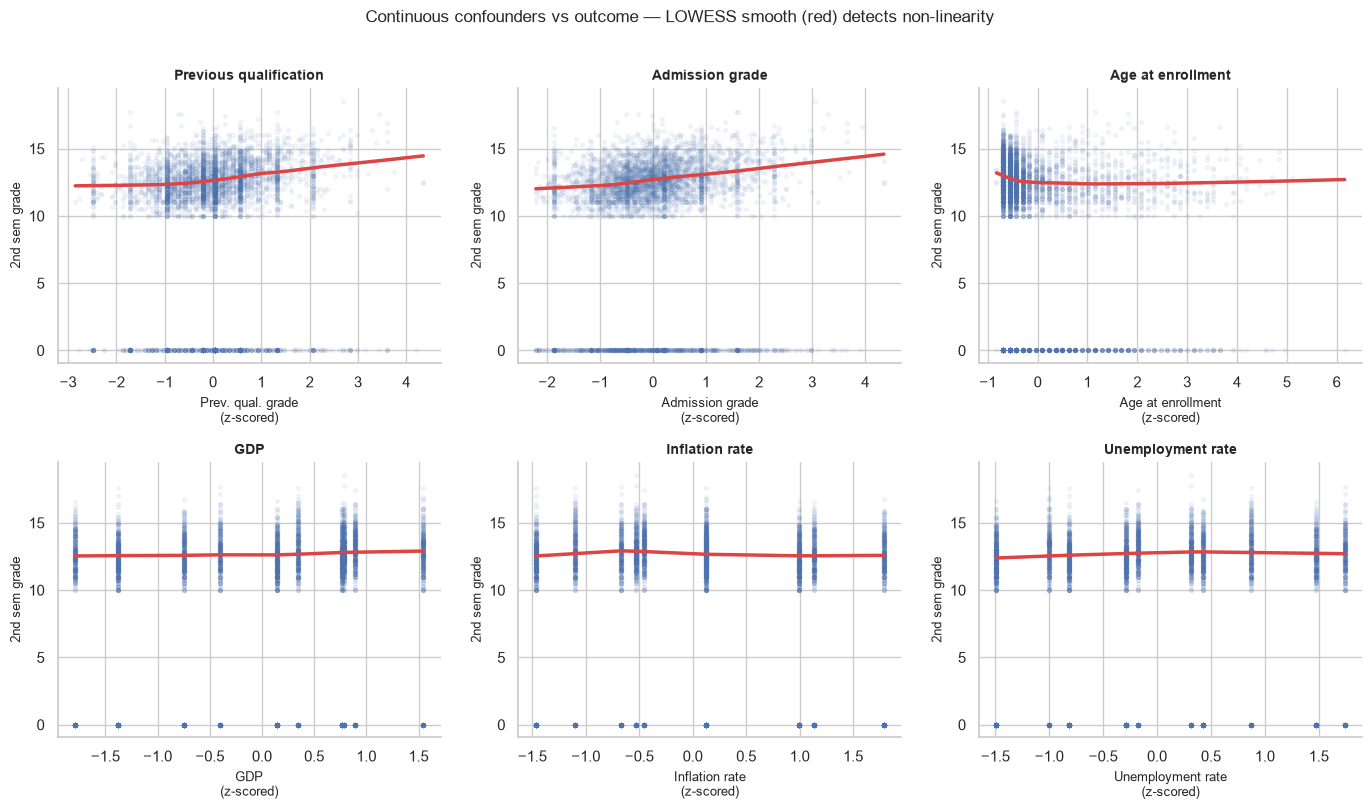

In [3]:
CONT_LABELS = {
    "Previous qualification (grade)": "Prev. qual. grade\n(z-scored)",
    "Admission grade":                "Admission grade\n(z-scored)",
    "Age at enrollment":              "Age at enrollment\n(z-scored)",
    "GDP":                            "GDP\n(z-scored)",
    "Inflation rate":                 "Inflation rate\n(z-scored)",
    "Unemployment rate":              "Unemployment rate\n(z-scored)",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flat, CONTINUOUS):
    sns.regplot(
        x=col, y=Y, data=df,
        lowess=True,
        scatter_kws={"alpha": 0.06, "s": 8, "color": "#4C72B0"},
        line_kws={"color": "#DD4444", "linewidth": 2.5},
        ax=ax,
    )
    ax.set_xlabel(CONT_LABELS[col], fontsize=9)
    ax.set_ylabel("2nd sem grade", fontsize=9)
    ax.set_title(col.split("(")[0].strip(), fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Continuous confounders vs outcome — LOWESS smooth (red) detects non-linearity",
    fontsize=12, y=1.01,
)
fig.tight_layout()
plt.show()

## 2. Parental Education vs Y — Ordered Violin Plots

Groups are ordered from lowest to highest qualification. A **non-linear** mean trend (red dashed line) would appear as a kink or jump — e.g. the step-up only at "Higher education" rather than a smooth monotone rise. The *Unknown* group (code 34) is shown last.

/var/folders/p_/7ffkm5mn1x3662hjwpjkb6fw0000gn/T/ipykernel_8256/2821968910.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(MQ_D, fontsize=8)
/var/folders/p_/7ffkm5mn1x3662hjwpjkb6fw0000gn/T/ipykernel_8256/2821968910.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(MQ_D, fontsize=8)


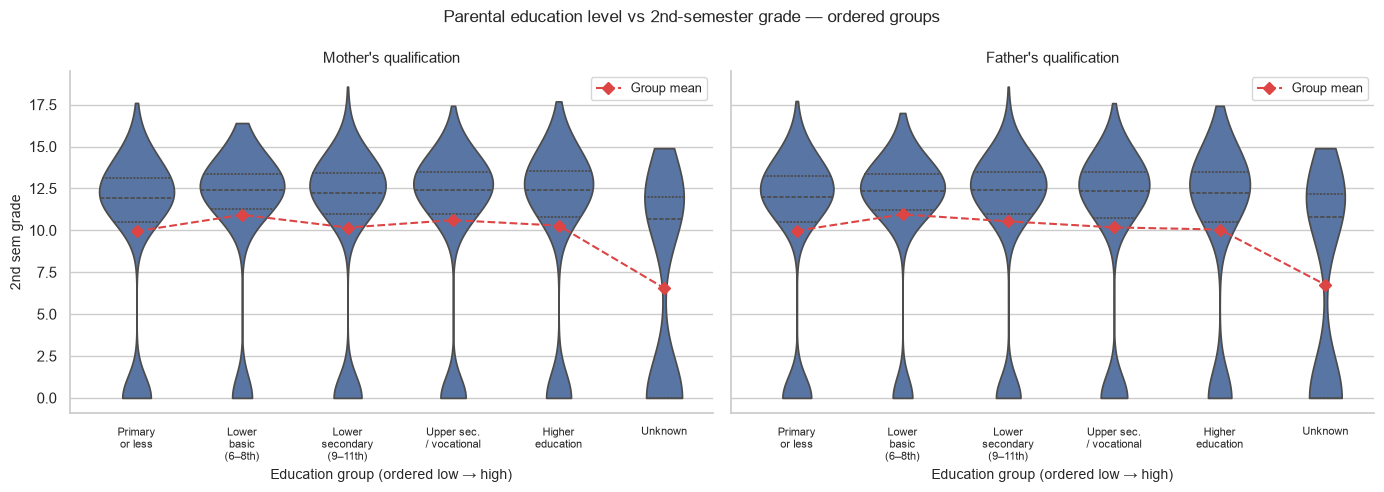

In [4]:
MQ_L = ["Primary_or_less", "Lower_basic_6th8th_grade",
        "Lower_secondary_9th11th_grade", "Upper_secondary_vocational",
        "Higher_education", "Unknown"]
MQ_D = ["Primary\nor less", "Lower\nbasic\n(6–8th)", "Lower\nsecondary\n(9–11th)",
        "Upper sec.\n/ vocational", "Higher\neducation", "Unknown"]

df["_mqual"] = decode_dummies(df, "Mothers_qualification", MQ_L)
df["_fqual"] = decode_dummies(df, "Fathers_qualification", MQ_L)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, col, title in [
    (axes[0], "_mqual", "Mother's qualification"),
    (axes[1], "_fqual", "Father's qualification"),
]:
    sns.violinplot(x=col, y=Y, data=df, order=MQ_L, ax=ax,
                   inner="quartile", cut=0, color="#4C72B0")
    means = df.groupby(col, observed=True)[Y].mean()
    ax.plot(range(len(MQ_L)), [means.get(g, np.nan) for g in MQ_L],
            "D--", color="#DD4444", markersize=6, lw=1.5, label="Group mean", zorder=5)
    ax.set_xticklabels(MQ_D, fontsize=8)
    ax.set_xlabel("Education group (ordered low → high)", fontsize=10)
    ax.set_ylabel("2nd sem grade", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Parental education level vs 2nd-semester grade — ordered groups", fontsize=12)
fig.tight_layout()
plt.show()

## 3. Parental Occupation vs Y

Violin plots show the full grade distribution per occupation group. The red dashed line connects group means — a non-flat or non-monotone line tells you the confounder is relevant and potentially non-linear.

/var/folders/p_/7ffkm5mn1x3662hjwpjkb6fw0000gn/T/ipykernel_8256/2382301606.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(OCC_D, fontsize=8)
/var/folders/p_/7ffkm5mn1x3662hjwpjkb6fw0000gn/T/ipykernel_8256/2382301606.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(OCC_D, fontsize=8)


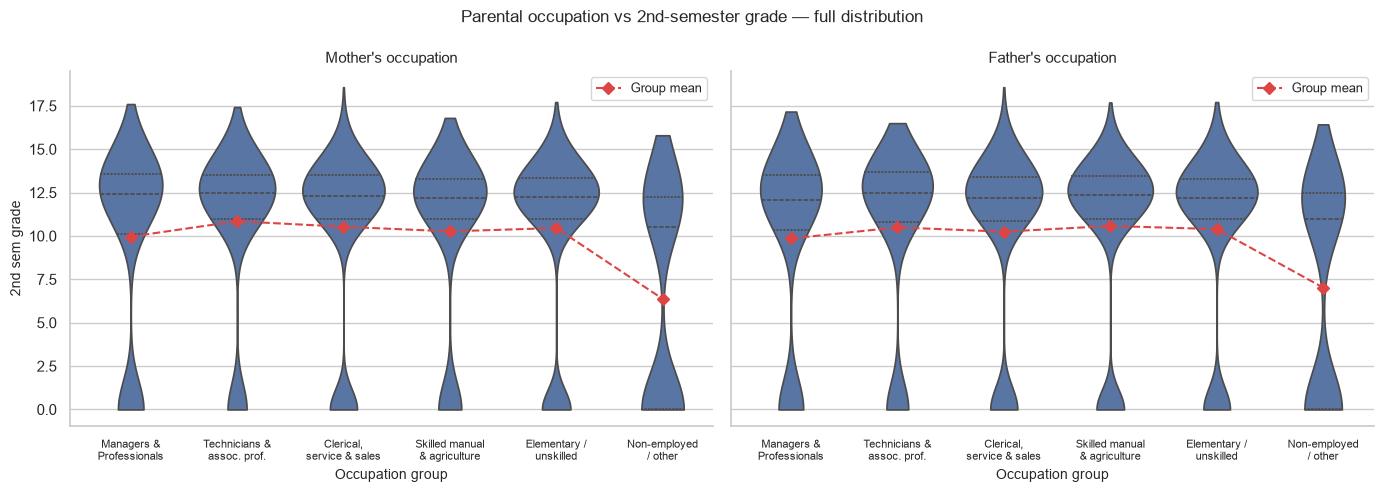

In [5]:
OCC_L = ["Managers_Professionals", "Technicians_associate_professionals",
         "Clerical_service_sales", "Skilled_manual_agriculture",
         "Elementary_unskilled", "Nonemployed_other"]
OCC_D = ["Managers &\nProfessionals", "Technicians &\nassoc. prof.",
         "Clerical,\nservice & sales", "Skilled manual\n& agriculture",
         "Elementary /\nunskilled", "Non-employed\n/ other"]

df["_mocc"] = decode_dummies(df, "Mothers_occupation", OCC_L)
df["_focc"] = decode_dummies(df, "Fathers_occupation", OCC_L)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, col, title in [
    (axes[0], "_mocc", "Mother's occupation"),
    (axes[1], "_focc", "Father's occupation"),
]:
    sns.violinplot(x=col, y=Y, data=df, order=OCC_L, ax=ax,
                   inner="quartile", cut=0, color="#4C72B0")
    means = df.groupby(col, observed=True)[Y].mean()
    ax.plot(range(len(OCC_L)), [means.get(g, np.nan) for g in OCC_L],
            "D--", color="#DD4444", markersize=6, lw=1.5, label="Group mean", zorder=5)
    ax.set_xticklabels(OCC_D, fontsize=8)
    ax.set_xlabel("Occupation group", fontsize=10)
    ax.set_ylabel("2nd sem grade", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Parental occupation vs 2nd-semester grade — full distribution", fontsize=12)
fig.tight_layout()
plt.show()

## 4. Course Field & Application Characteristics vs Y

Box plots with overlaid group means (red diamonds). Non-flat mean lines and non-overlapping boxes indicate the variable shifts the grade distribution — and therefore matters as a confounder. Application order is an ordinal preference ranking (1st choice → 4th or below).

/var/folders/p_/7ffkm5mn1x3662hjwpjkb6fw0000gn/T/ipykernel_8256/2418704129.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(display, fontsize=8)
/var/folders/p_/7ffkm5mn1x3662hjwpjkb6fw0000gn/T/ipykernel_8256/2418704129.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(display, fontsize=8)
/var/folders/p_/7ffkm5mn1x3662hjwpjkb6fw0000gn/T/ipykernel_8256/2418704129.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(display, fontsize=8)
/var/folders/p_/7ffkm5mn1x3662hjwpjkb6fw0000gn/T/ipykernel_8256/2418704129.py:40: UserWarning: set_ticklabels() should only be used with

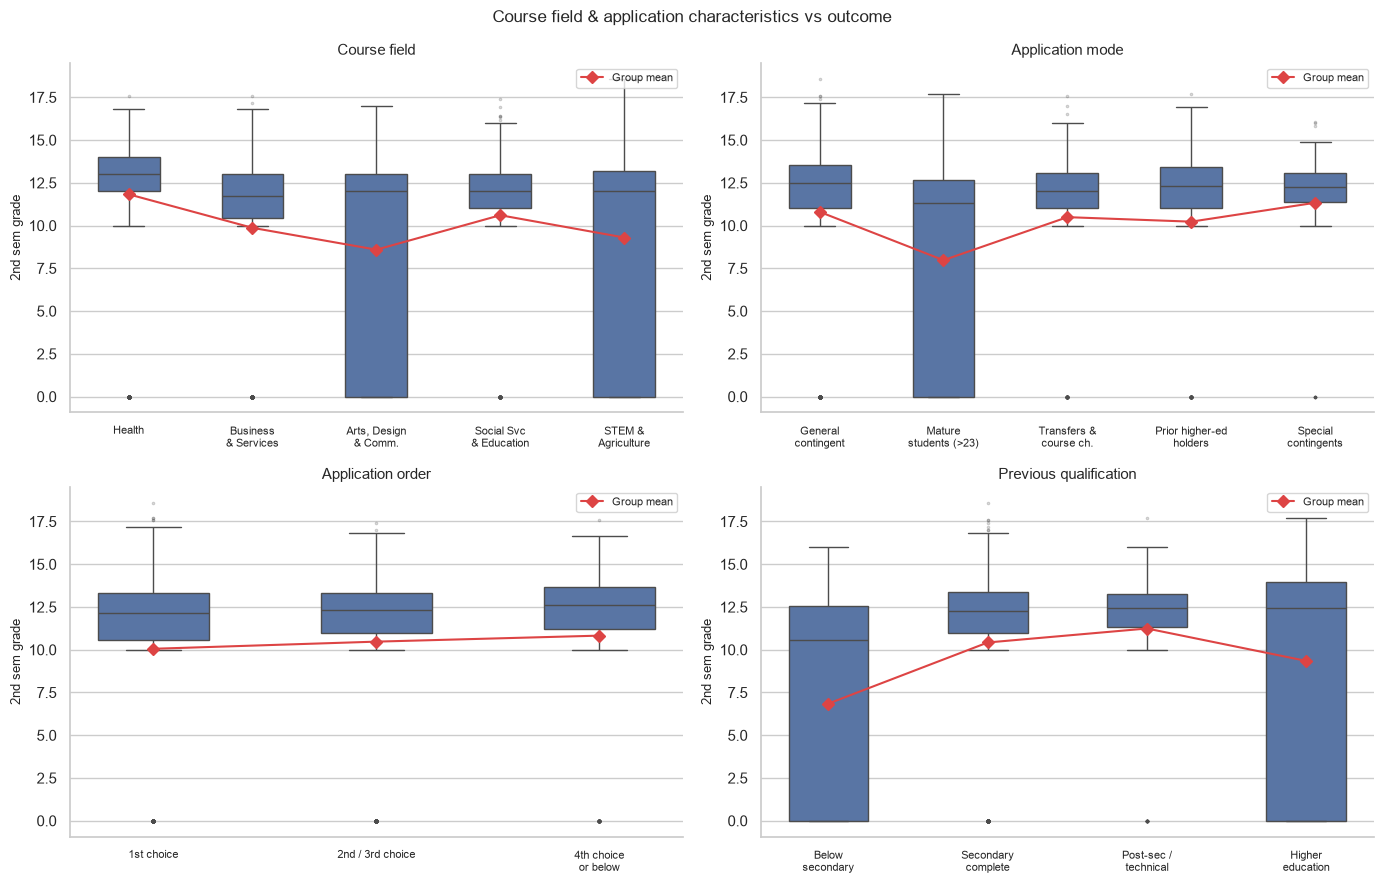

In [6]:
COURSE_L    = ["Health", "Business_Services", "Arts_Design_Communication",
               "Social_Service_Education", "STEM_Agriculture"]
COURSE_D    = ["Health", "Business\n& Services", "Arts, Design\n& Comm.",
               "Social Svc\n& Education", "STEM &\nAgriculture"]

APPMODE_L   = ["General_contingent_standard_phases", "Mature_students_over_23",
               "Transfers_course_changes", "Prior_highered_diploma_holders",
               "Special_contingents_ordinances_international"]
APPMODE_D   = ["General\ncontingent", "Mature\nstudents (>23)", "Transfers &\ncourse ch.",
               "Prior higher-ed\nholders", "Special\ncontingents"]

APPORDER_L  = ["Top_choice_1st", "Second_or_third_choice", "Lower_preference_4th_or_below"]
APPORDER_D  = ["1st choice", "2nd / 3rd choice", "4th choice\nor below"]

PREVQ_L     = ["Below_secondary", "Secondary_complete",
               "Postsecondary_technical_nondegree", "Higher_education"]
PREVQ_D     = ["Below\nsecondary", "Secondary\ncomplete", "Post-sec /\ntechnical", "Higher\neducation"]

df["_course"]    = decode_dummies(df, "Course", COURSE_L)
df["_app_mode"]  = decode_dummies(df, "Application_mode", APPMODE_L)
df["_app_order"] = decode_dummies(df, "Application_order", APPORDER_L)
df["_prev_qual"] = decode_dummies(df, "Previous_qualification", PREVQ_L)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

specs = [
    (axes[0, 0], "_course",    COURSE_L,   COURSE_D,   "Course field"),
    (axes[0, 1], "_app_mode",  APPMODE_L,  APPMODE_D,  "Application mode"),
    (axes[1, 0], "_app_order", APPORDER_L, APPORDER_D, "Application order"),
    (axes[1, 1], "_prev_qual", PREVQ_L,    PREVQ_D,    "Previous qualification"),
]

for ax, col, order, display, title in specs:
    sns.boxplot(x=col, y=Y, data=df, order=order, ax=ax,
                width=0.5, color="#4C72B0",
                flierprops={"marker": ".", "alpha": 0.3, "markersize": 3})
    means = df.groupby(col, observed=True)[Y].mean()
    ax.plot(range(len(order)), [means.get(g, np.nan) for g in order],
            "D-", color="#DD4444", markersize=6, lw=1.5, label="Group mean", zorder=5)
    ax.set_xticklabels(display, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("2nd sem grade", fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Course field & application characteristics vs outcome", fontsize=12)
fig.tight_layout()
plt.show()

## 5. Binary Confounders vs Y — Mean Grade Comparison

For each binary variable, compare the mean outcome between group 0 and group 1 (bars ± 95% CI). Wide gaps signal strong confounding. The **Scholarship holder (D)** bar is the naive unadjusted difference — the DML estimate will be smaller once we condition on X.

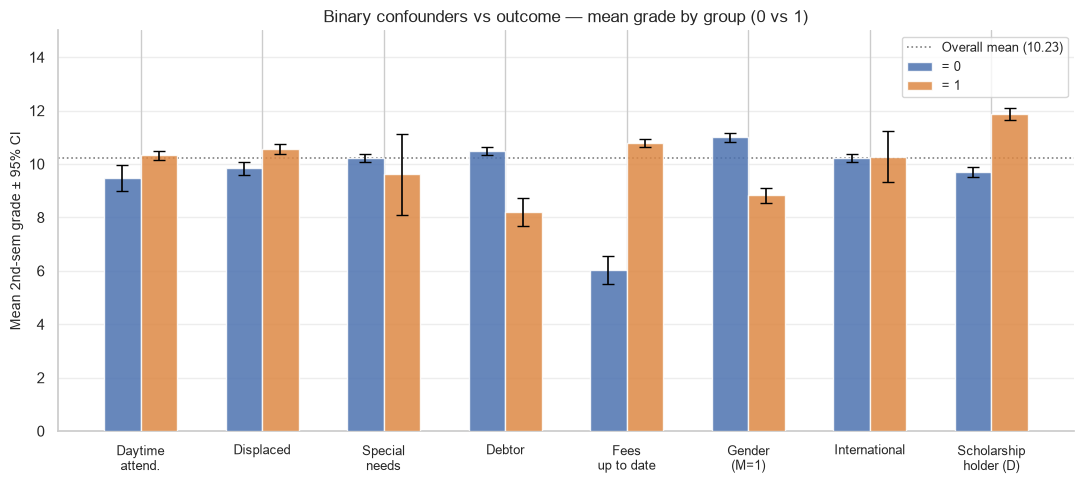

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

short = {
    "Daytime/evening attendance": "Daytime\nattend.",
    "Displaced":                  "Displaced",
    "Educational special needs":  "Special\nneeds",
    "Debtor":                     "Debtor",
    "Tuition fees up to date":    "Fees\nup to date",
    "Gender":                     "Gender\n(M=1)",
    "International":              "International",
    D:                            "Scholarship\nholder (D)",
}

vars_ = BINARY + [D]
x = np.arange(len(vars_))
w = 0.30

m0 = [df.loc[df[v] == 0, Y].mean() for v in vars_]
m1 = [df.loc[df[v] == 1, Y].mean() for v in vars_]
e0 = [1.96 * df.loc[df[v] == 0, Y].sem() for v in vars_]
e1 = [1.96 * df.loc[df[v] == 1, Y].sem() for v in vars_]

ax.bar(x - w/2, m0, w, label="= 0", color="#4C72B0", alpha=0.85, zorder=3)
ax.bar(x + w/2, m1, w, label="= 1", color="#DD8844", alpha=0.85, zorder=3)
ax.errorbar(x - w/2, m0, yerr=e0, fmt="none", color="black", capsize=4, lw=1.2, zorder=4)
ax.errorbar(x + w/2, m1, yerr=e1, fmt="none", color="black", capsize=4, lw=1.2, zorder=4)

ax.axhline(df[Y].mean(), color="grey", linestyle=":", lw=1.2,
           label=f"Overall mean ({df[Y].mean():.2f})")
ax.set_xticks(x)
ax.set_xticklabels([short[v] for v in vars_], fontsize=9)
ax.set_ylabel("Mean 2nd-sem grade ± 95% CI", fontsize=10)
ax.set_title("Binary confounders vs outcome — mean grade by group (0 vs 1)", fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 15)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.35)
fig.tight_layout()
plt.show()

## 6. Baseline Effect — Naive Grade Gap (Scholarship vs No Scholarship)

Raw difference in mean 2nd-semester grade between scholarship holders and non-holders, **before** controlling for confounders. This is the unadjusted estimate that DML will correct for selection bias.

In [8]:
from scipy import stats

g0 = df.loc[df[D] == 0, Y]
g1 = df.loc[df[D] == 1, Y]

mean0, mean1 = g0.mean(), g1.mean()
diff = mean1 - mean0

# 95% CI for the difference via Welch's t-test
t_stat, p_val = stats.ttest_ind(g1, g0, equal_var=False)
se_diff = np.sqrt(g0.var(ddof=1) / len(g0) + g1.var(ddof=1) / len(g1))
ci_lo, ci_hi = diff - 1.96 * se_diff, diff + 1.96 * se_diff

print(f"{'Group':<25} {'N':>6}  {'Mean grade':>12}  {'Std dev':>8}")
print("-" * 57)
print(f"{'No scholarship (D=0)':<25} {len(g0):>6}  {mean0:>12.3f}  {g0.std():>8.3f}")
print(f"{'Scholarship (D=1)':<25} {len(g1):>6}  {mean1:>12.3f}  {g1.std():>8.3f}")
print("-" * 57)
print(f"\nBaseline effect (D=1 minus D=0) : {diff:+.3f} grade points")
print(f"95% CI                          : [{ci_lo:+.3f}, {ci_hi:+.3f}]")
print(f"Welch t-statistic               : {t_stat:.3f}")
print(f"p-value                         : {p_val:.4f}")
print(f"\n  → Scholarship holders score on average {abs(diff):.2f} points")
print(f"    {'higher' if diff > 0 else 'lower'} than non-holders (unadjusted).")
print(f"    DML will remove confounding to isolate the causal effect.")

Group                          N    Mean grade   Std dev
---------------------------------------------------------
No scholarship (D=0)        3325         9.687     5.496
Scholarship (D=1)           1099        11.873     3.787
---------------------------------------------------------

Baseline effect (D=1 minus D=0) : +2.185 grade points
95% CI                          : [+1.894, +2.477]
Welch t-statistic               : 14.688
p-value                         : 0.0000

  → Scholarship holders score on average 2.19 points
    higher than non-holders (unadjusted).
    DML will remove confounding to isolate the causal effect.
